In [15]:

import numpy as np
import pandas as pd
import config as cfg

from scipy.stats import sem, t

matplotlib_style = 'default'
import matplotlib.pyplot as plt; plt.style.use(matplotlib_style)
plt.rcParams.update({
    'axes.labelsize': 'large',
    'axes.titlesize': 'x-large',  # Set larger title size
    'font.size': 14.0,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{bm}'
})

filename = f"{cfg.RESULTS_DIR}/dgp_error_over_ktau.csv"
df = pd.read_csv(filename)

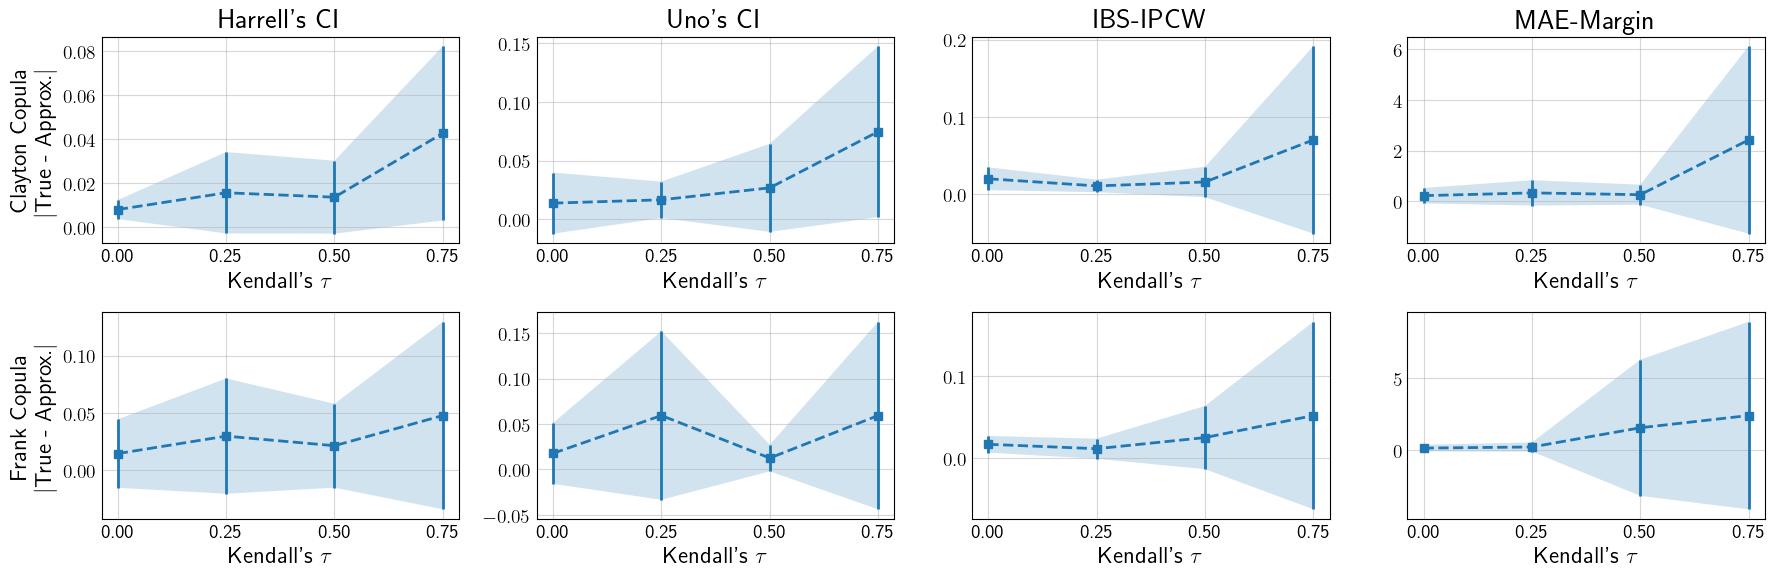

In [18]:
# Group by k_tau and compute the mean and std across seeds
grouped = df.groupby(['copula_name', 'k_tau'])
mean_errors = grouped.mean().reset_index()
std_errors = grouped.std().reset_index()

# Define the error columns and their plot styles
error_columns = [('ci_harrell_error', "CI"), ("ci_uno_error", "CI"),
                 ('ibs_ipcw_error', "IBS"), ('mae_margin_error', "MAE")]
error_names = ["Harrell\'s CI", "Uno\'s CI", "IBS-IPCW", "MAE-Margin"]

# Create subplots (2 rows, 4 columns)
fig, axs = plt.subplots(2, 4, figsize=(18, 6))

# Row mapping for Clayton and Frank copulas
copula_rows = {'clayton': 0, 'frank': 1}

# Loop through the metrics and copula types
for col_idx, (column, title) in enumerate(error_columns):
    for copula_name, row_idx in copula_rows.items():
        # Filter data for the current copula
        copula_data = mean_errors[mean_errors['copula_name'] == copula_name]
        copula_std = std_errors[std_errors['copula_name'] == copula_name]
        
        # Plot the metric with error bars and shaded area
        axs[row_idx, col_idx].errorbar(
            copula_data['k_tau'], copula_data[column], 
            yerr=copula_std[column], fmt='s', linestyle='dashed', 
            label=f"{copula_name.capitalize()} {title}", alpha=1,
            linewidth=2, markersize=6
        )
        axs[row_idx, col_idx].fill_between(
            copula_data['k_tau'], 
            copula_data[column] - copula_std[column], 
            copula_data[column] + copula_std[column], 
            alpha=0.2
        )
        
        # Set axis labels and titles
        if row_idx == 0:
            axs[row_idx, col_idx].set_title(f"{error_names[col_idx]}")
        axs[row_idx, col_idx].set_xticks([0.0, 0.25, 0.5, 0.75])
        axs[row_idx, col_idx].set_xticklabels(['0.00', '0.25', '0.50', '0.75'])
        if col_idx == 0:
            axs[row_idx, col_idx].set_ylabel(f"{copula_name.capitalize()} Copula \n" + r"$|$True - Approx.$|$")
        axs[row_idx, col_idx].grid(True, alpha=0.5)
        
        axs[row_idx, col_idx].tick_params(axis='y', which='both', length=0)
        axs[row_idx, col_idx].tick_params(axis='x', which='both', length=0)
        
        axs[row_idx, col_idx].set_xlabel("Kendall's $\\tau$")
        
# Adjust layout for better spacing
plt.tight_layout()

# Save figure
plt.savefig(f"{cfg.PLOTS_DIR}/dgp_error_over_ktau.pdf", format='pdf', bbox_inches='tight')

# Show the plot
plt.show()